In [3]:
#Import packages
import pandas as pd
import numpy as np
import math
import os
from astropy.io import fits
import healpy as hp
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.layers import Normalization
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

Current working directory: /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data


In [ ]:
from CMBFeatureNet import read_map
test_path = "./simulated_maps/lcdm/"
map_temp_data = read_map(test_path + 'cmb_map_0.fits')

Filename: ./simulated_maps/lcdm/cmb_map_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   12288R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


NSIDE: 1024


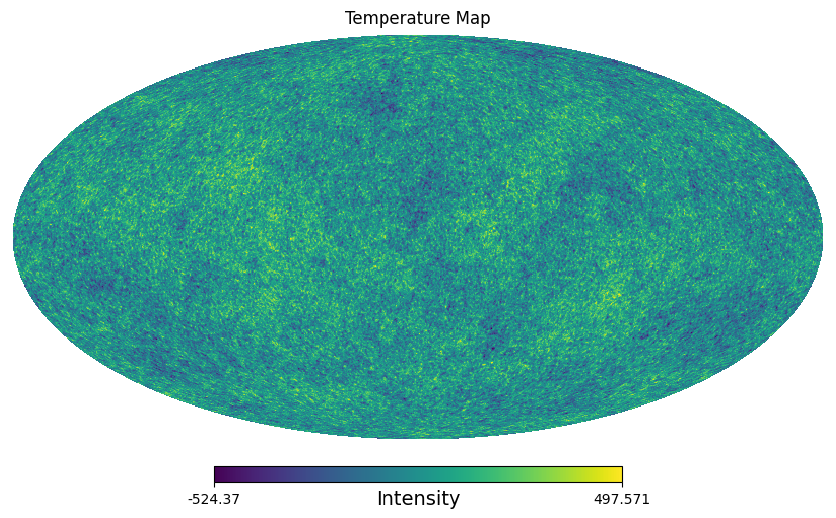

In [116]:
#Visualize the map
nside = hp.npix2nside(len(map_temp_data))
print(f"NSIDE: {nside}")

#Plot
hp.mollview(map_temp_data, title="Temperature Map", unit="Intensity")
plt.show()

In [117]:
#Conerting Dls to the c_ls^TT
def Cls(l,DlTT):
    ClTT = [(2*math.pi)/(l[i]*(l[i]+1))*DlTT[i] for i in range(len(l))]
    return ClTT

def Dls(l, ClTT):
    DlTT = [l[i]*(l[i]+1)/(2*np.pi)*ClTT[i] for i in range(len(l))]
    return DlTT

In [118]:
#Read the cmb angular power spectra
simulated_dlstt = np.loadtxt('./simulated_data/simulated_ang_power_spectra/dlstt_lcdm_0.csv', delimiter=',')
simulated_dlste = np.loadtxt('./simulated_data/simulated_ang_power_spectra/dlste_lcdm_0.csv', delimiter=',')
simulated_dlsee = np.loadtxt('./simulated_data/simulated_ang_power_spectra/dlsee_lcdm_0.csv', delimiter=',')

In [119]:
map_Qpol_data = read_map(test_path + 'cmb_pol_map_Q_0.fits')
map_Upol_data = read_map(test_path + 'cmb_pol_map_U_0.fits')

Filename: ./simulated_maps/lcdm/cmb_pol_map_Q_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   12288R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)
Filename: ./simulated_maps/lcdm/cmb_pol_map_U_0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  xtension      1 BinTableHDU     18   12288R x 1C   [1024D]   
ColDefs(
    name = 'T'; format = '1024D'
)


NSIDE: 1024


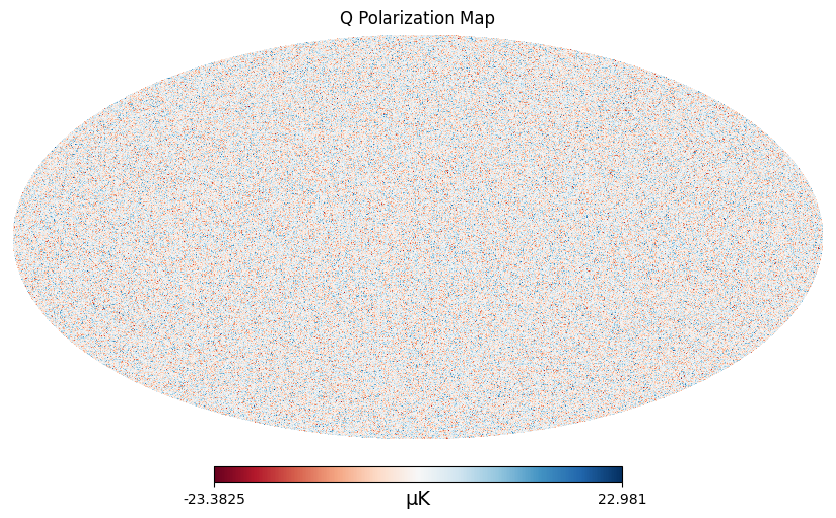

In [120]:
#Visualize the Q map
nside = hp.npix2nside(len(map_Qpol_data))
print(f"NSIDE: {nside}")

hp.mollview(map_Qpol_data, title="Q Polarization Map", unit="μK", cmap="RdBu")
plt.show()

NSIDE: 1024


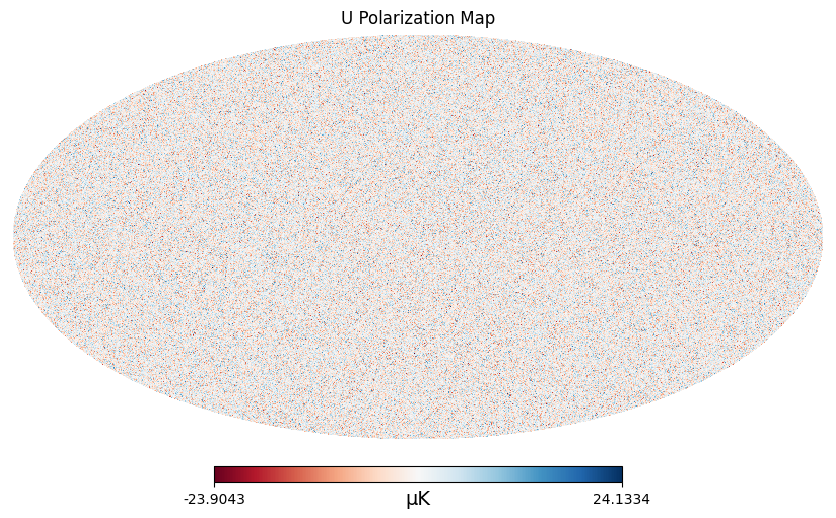

In [121]:
#Visualize the Q map
nside = hp.npix2nside(len(map_Upol_data))
print(f"NSIDE: {nside}")

hp.mollview(map_Upol_data, title="U Polarization Map", unit="μK", cmap="RdBu")
plt.show()

In [139]:
# Combine maps into an input list
maps = [map_temp_data, map_Qpol_data, map_Upol_data]

# Compute the power spectra
cl_tt_map, cl_ee_map, cl_bb_map, cl_te_map, cl_eb_map, cl_tb_map = hp.anafast(maps, pol=True)

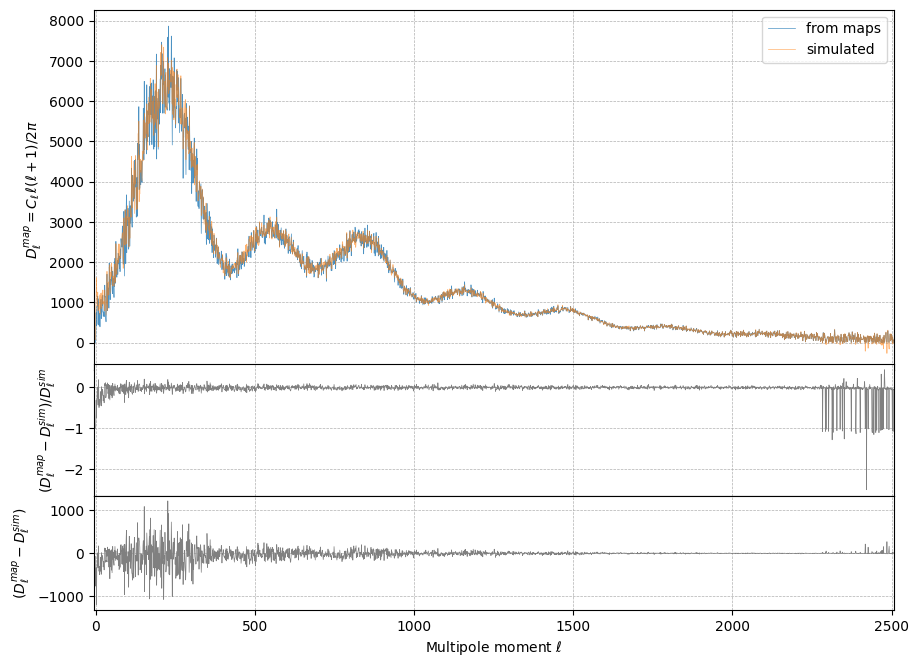

In [136]:
ell = np.arange(len(cl_tt_map))

fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:len(simulated_dlstt[1])], Dls(ell, cl_tt_map)[:len(simulated_dlstt[1])], 
            label='from maps', linewidth=0.5, alpha=0.8)
frame1.plot(ell[:len(simulated_dlstt[1])], simulated_dlstt[1], 
            label='simulated', linewidth=0.5, alpha=0.6)
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{map}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, len(simulated_dlstt[1]))
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()

#Lower plots (Difference)
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1) 
diff = (Dls(ell, cl_tt_map)[:len(simulated_dlstt[1])] - simulated_dlstt[1]) / simulated_dlstt[1]
frame2.plot(ell[:len(simulated_dlstt[1])], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{map} - D_\ell^{sim}) / D_\ell^{sim}$')
frame2.tick_params(axis='x', labelsize=0.1)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)

frame3 = fig.add_axes((.1, 0., .8, 0.19), sharex=frame1) 
diff = (Dls(ell, cl_tt_map)[:len(simulated_dlstt[1])] - simulated_dlstt[1])
frame3.plot(ell[:len(simulated_dlstt[1])], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame3.set_xlabel(r'Multipole moment $\ell$')
frame3.set_ylabel(r'$(D_\ell^{map} - D_\ell^{sim})$')
frame3.tick_params(axis='x', labelsize=10)
frame3.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

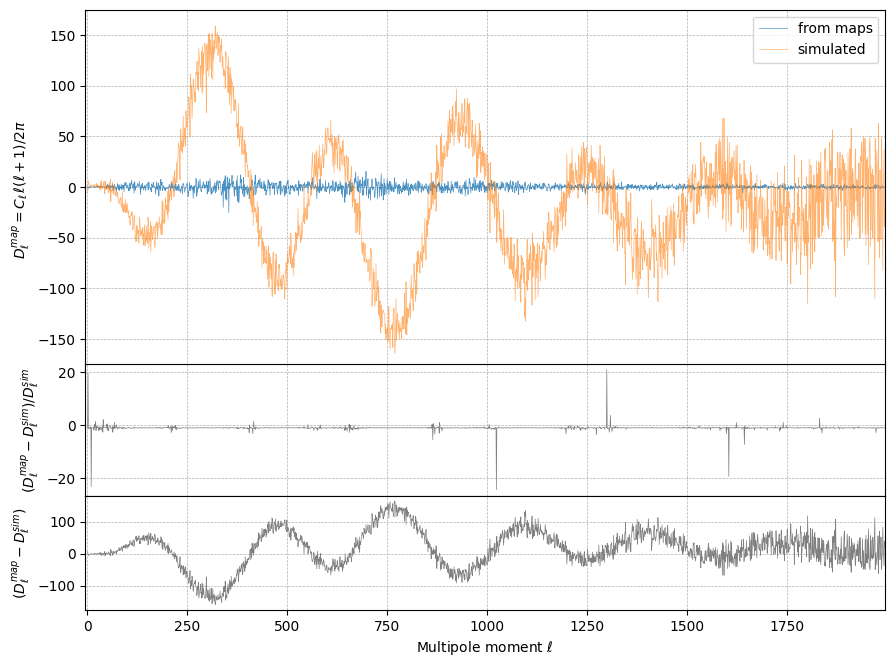

In [137]:
fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:len(simulated_dlste[1])], Dls(ell, cl_te_map)[:len(simulated_dlste[1])], 
            label='from maps', linewidth=0.5, alpha=0.8)
frame1.plot(ell[:len(simulated_dlste[1])], simulated_dlste[1], 
            label='simulated', linewidth=0.5, alpha=0.6)
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{map}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, len(simulated_dlste[1]))
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()

#Lower plots (Difference)
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1) 
diff = (Dls(ell, cl_te_map)[:len(simulated_dlste[1])] - simulated_dlste[1]) / simulated_dlste[1]
frame2.plot(ell[:len(simulated_dlste[1])], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{map} - D_\ell^{sim}) / D_\ell^{sim}$')
frame2.tick_params(axis='x', labelsize=0.1)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)

frame3 = fig.add_axes((.1, 0., .8, 0.19), sharex=frame1) 
diff = (Dls(ell, cl_te_map)[:len(simulated_dlste[1])] - simulated_dlste[1])
frame3.plot(ell[:len(simulated_dlste[1])], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame3.set_xlabel(r'Multipole moment $\ell$')
frame3.set_ylabel(r'$(D_\ell^{map} - D_\ell^{sim})$')
frame3.tick_params(axis='x', labelsize=10)
frame3.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

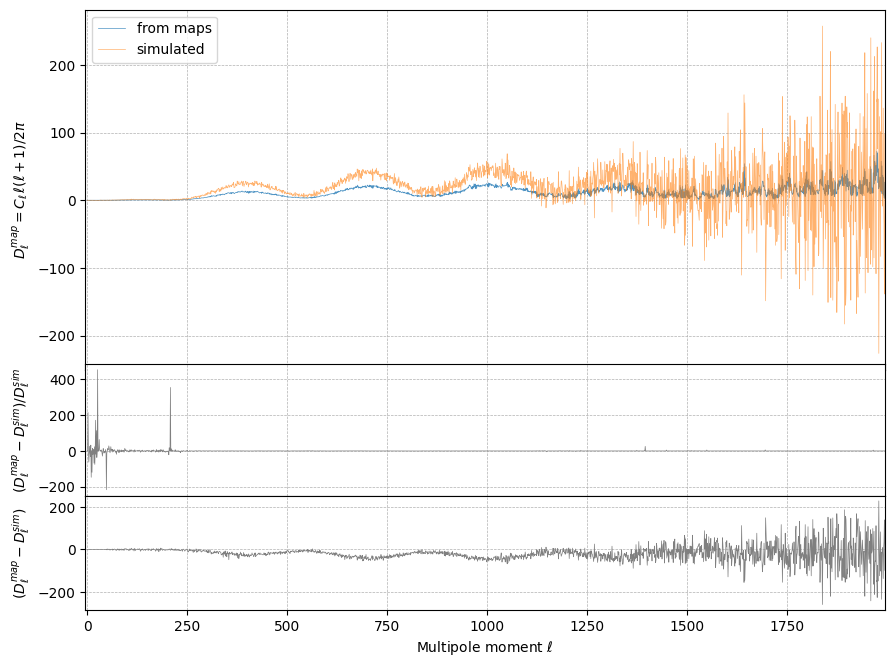

In [138]:
fig = plt.figure(figsize=(10, 6))

#Upper plot (Power Spectrum)
frame1 = fig.add_axes((.1, .4, .8, .6))
frame1.plot(ell[:len(simulated_dlsee[1])], Dls(ell, cl_ee_map)[:len(simulated_dlsee[1])], 
            label='from maps', linewidth=0.5, alpha=0.8)
frame1.plot(ell[:len(simulated_dlsee[1])], simulated_dlsee[1], 
            label='simulated', linewidth=0.5, alpha=0.6)
frame1.set_xlabel(r'Multipole moment $\ell$')
frame1.set_ylabel(r'$D_\ell^{map}=C_\ell \, \ell(\ell+1)/2\pi$')
frame1.set_xlim(-5, len(simulated_dlsee[1]))
frame1.tick_params(axis='x', labelsize=0.1)
frame1.grid(True, which='both', linestyle='--', linewidth=0.5)
frame1.legend()

#Lower plots (Difference)
frame2 = fig.add_axes((.1, .19, .8, .22), sharex=frame1) 
diff = (Dls(ell, cl_te_map)[:len(simulated_dlsee[1])] - simulated_dlsee[1]) / simulated_dlsee[1]
frame2.plot(ell[:len(simulated_dlsee[1])], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame2.set_xlabel(r'Multipole moment $\ell$')
frame2.set_ylabel(r'$(D_\ell^{map} - D_\ell^{sim}) / D_\ell^{sim}$')
frame2.tick_params(axis='x', labelsize=0.1)
frame2.grid(True, which='both', linestyle='--', linewidth=0.5)

frame3 = fig.add_axes((.1, 0., .8, 0.19), sharex=frame1) 
diff = (Dls(ell, cl_te_map)[:len(simulated_dlsee[1])] - simulated_dlsee[1])
frame3.plot(ell[:len(simulated_dlsee[1])], diff, label='Percentage difference', linewidth=0.5, color='gray')
frame3.set_xlabel(r'Multipole moment $\ell$')
frame3.set_ylabel(r'$(D_\ell^{map} - D_\ell^{sim})$')
frame3.tick_params(axis='x', labelsize=10)
frame3.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()